**1 - Mount & Import**

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os
from collections import Counter
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2 - Load Data**

In [15]:
path_d2 = "/content/drive/MyDrive/SKRIPSI/CODE/HASIL_SPLITTING"
df2_train = pd.read_csv(f"{path_d2}/data_train.csv")

print(f"✅ Dataset 2 Train : {len(df2_train)} data")
print(f"   Non-Sarkasme   : {(df2_train['label']==0).sum()}")
print(f"   Sarkasme       : {(df2_train['label']==1).sum()}")

✅ Dataset 2 Train : 1777 data
   Non-Sarkasme   : 1514
   Sarkasme       : 263


**3 - Buat Lexicon SVM**

In [16]:
print("📍 Membuat Lexicon SVM dari D2 train...")

df_sarkasme_svm     = df2_train[df2_train['label'] == 1]
df_non_sarkasme_svm = df2_train[df2_train['label'] == 0]

freq_sarkasme_svm     = Counter(" ".join(df_sarkasme_svm['text_clean'].dropna().values).split())
freq_non_sarkasme_svm = Counter(" ".join(df_non_sarkasme_svm['text_clean'].dropna().values).split())

lexicon_svm = []
for kata, frek in freq_sarkasme_svm.items():
    frek_non = freq_non_sarkasme_svm.get(kata, 0)
    skor = frek / (frek + frek_non + 1)
    lexicon_svm.append({
        'kata'             : kata,
        'frek_sarkasme'    : frek,
        'frek_non_sarkasme': frek_non,
        'skor_sarkasme'    : skor
    })

df_lexicon_svm = pd.DataFrame(lexicon_svm)
df_lexicon_svm = df_lexicon_svm.sort_values(
    'skor_sarkasme', ascending=False).reset_index(drop=True)

print(f"✅ Lexicon SVM selesai!")
print(f"📊 Total kata : {len(df_lexicon_svm)}")
print(f"\nTop 20 kata:")
print(df_lexicon_svm.head(20).to_string())

📍 Membuat Lexicon SVM dari D2 train...
✅ Lexicon SVM selesai!
📊 Total kata : 2179

Top 20 kata:
          kata  frek_sarkasme  frek_non_sarkasme  skor_sarkasme
0          tau             12                  0       0.923077
1         kira              8                  0       0.888889
2          kok             14                  1       0.875000
3          lah              6                  0       0.857143
4         ilmu              4                  0       0.800000
5        jujur              4                  0       0.800000
6           kl              4                  0       0.800000
7       selalu              4                  0       0.800000
8       maling              4                  0       0.800000
9    rakyatnya              4                  0       0.800000
10     artinya              4                  0       0.800000
11          eh              4                  0       0.800000
12      kenapa             11                  2       0.785714
13     d

**4 - Buat Lexicon IndoBERT**

In [17]:
print("📍 Membuat Lexicon IndoBERT dari D2 train...")

df_sarkasme_ib     = df2_train[df2_train['label'] == 1]
df_non_sarkasme_ib = df2_train[df2_train['label'] == 0]

freq_sarkasme_ib     = Counter(" ".join(df_sarkasme_ib['text_clean'].dropna().values).split())
freq_non_sarkasme_ib = Counter(" ".join(df_non_sarkasme_ib['text_clean'].dropna().values).split())

lexicon_indobert = []
for kata, frek in freq_sarkasme_ib.items():
    frek_non = freq_non_sarkasme_ib.get(kata, 0)
    skor = frek / (frek + frek_non + 1)
    lexicon_indobert.append({
        'kata'             : kata,
        'frek_sarkasme'    : frek,
        'frek_non_sarkasme': frek_non,
        'skor_sarkasme'    : skor
    })

df_lexicon_indobert = pd.DataFrame(lexicon_indobert)
df_lexicon_indobert = df_lexicon_indobert.sort_values(
    'skor_sarkasme', ascending=False).reset_index(drop=True)

print(f"✅ Lexicon IndoBERT selesai!")
print(f"📊 Total kata : {len(df_lexicon_indobert)}")
print(f"\nTop 20 kata:")
print(df_lexicon_indobert.head(20).to_string())

📍 Membuat Lexicon IndoBERT dari D2 train...
✅ Lexicon IndoBERT selesai!
📊 Total kata : 2179

Top 20 kata:
          kata  frek_sarkasme  frek_non_sarkasme  skor_sarkasme
0          tau             12                  0       0.923077
1         kira              8                  0       0.888889
2          kok             14                  1       0.875000
3          lah              6                  0       0.857143
4         ilmu              4                  0       0.800000
5        jujur              4                  0       0.800000
6           kl              4                  0       0.800000
7       selalu              4                  0       0.800000
8       maling              4                  0       0.800000
9    rakyatnya              4                  0       0.800000
10     artinya              4                  0       0.800000
11          eh              4                  0       0.800000
12      kenapa             11                  2       0.78571

**5 - Visualisasi Top 10 Kata**

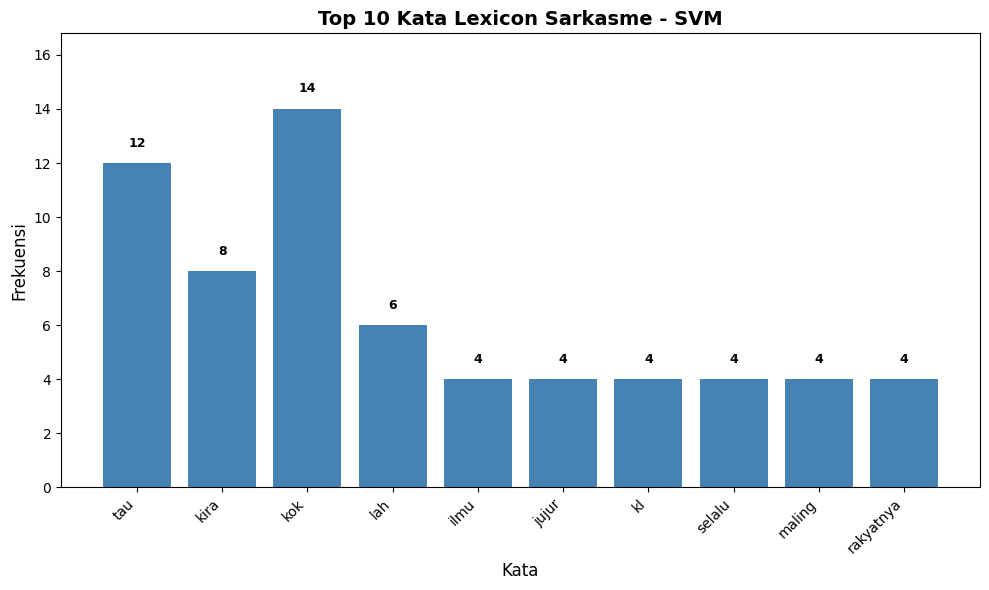

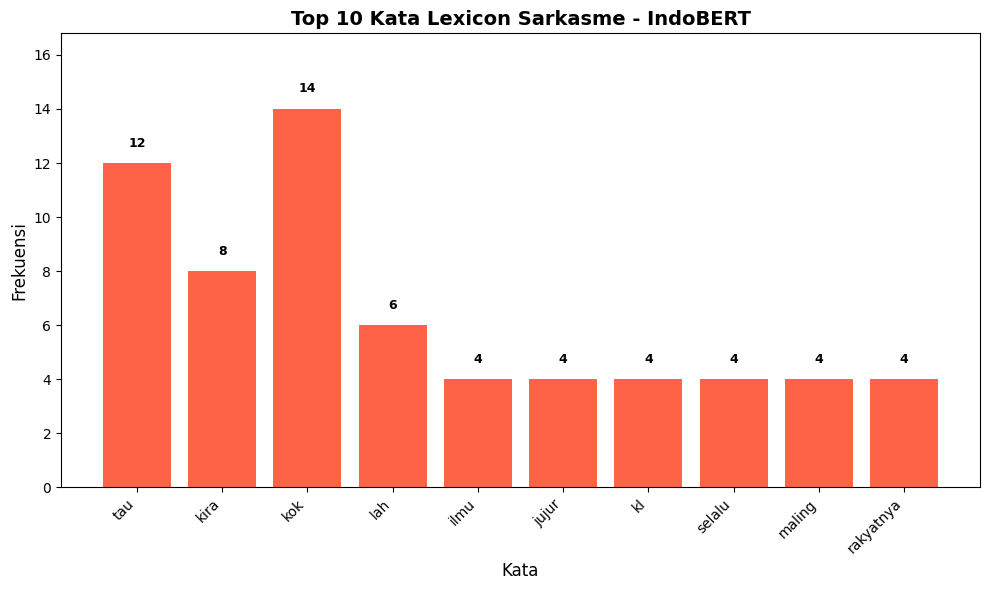

✅ Visualisasi berhasil disimpan!


In [18]:
save_path = "/content/drive/MyDrive/SKRIPSI/CODE/LEXICON_V3"
os.makedirs(save_path, exist_ok=True)

# Lexicon SVM
top10_svm = df_lexicon_svm.head(10)
plt.figure(figsize=(10, 6))
bars = plt.bar(top10_svm['kata'], top10_svm['frek_sarkasme'], color='steelblue')
for bar, val in zip(bars, top10_svm['frek_sarkasme']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.xlabel('Kata', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.title('Top 10 Kata Lexicon Sarkasme - SVM', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, top10_svm['frek_sarkasme'].max() * 1.2)
plt.tight_layout()
plt.savefig(f"{save_path}/top10_lexicon_svm.png", dpi=300)
plt.show()

# Lexicon IndoBERT
top10_indobert = df_lexicon_indobert.head(10)
plt.figure(figsize=(10, 6))
bars = plt.bar(top10_indobert['kata'], top10_indobert['frek_sarkasme'], color='tomato')
for bar, val in zip(bars, top10_indobert['frek_sarkasme']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.xlabel('Kata', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.title('Top 10 Kata Lexicon Sarkasme - IndoBERT', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, top10_indobert['frek_sarkasme'].max() * 1.2)
plt.tight_layout()
plt.savefig(f"{save_path}/top10_lexicon_indobert.png", dpi=300)
plt.show()

print("✅ Visualisasi berhasil disimpan!")

**6 - Simpan Lexicon**

In [19]:
df_lexicon_svm.to_csv(f"{save_path}/lexicon_svm.csv",           index=False)
df_lexicon_indobert.to_csv(f"{save_path}/lexicon_indobert.csv", index=False)

print(f"✅ Semua lexicon berhasil disimpan ke {save_path}")
print(f"📊 Lexicon SVM      : {len(df_lexicon_svm)} kata")
print(f"📊 Lexicon IndoBERT : {len(df_lexicon_indobert)} kata")

✅ Semua lexicon berhasil disimpan ke /content/drive/MyDrive/SKRIPSI/CODE/LEXICON_V3
📊 Lexicon SVM      : 2179 kata
📊 Lexicon IndoBERT : 2179 kata
